# Homework 4 - Building a Mini GPT from Scratch



In [25]:
import math
import os
import random
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 6812
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Part 1 - Data Preparation


In [26]:
from pathlib import Path

candidate_paths = [
    Path("shakespeare.txt"),
    Path("Shakespeare.txt"),
    Path("/content/shakespeare.txt"),
    Path("/content/Shakespeare.txt"),
    Path("/mnt/data/shakespeare.txt"),
    Path("/mnt/data/Shakespeare.txt"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

# In Colab, this opens a file picker if the course file is not already uploaded.
if data_path is None:
    try:
        from google.colab import files
        print("Upload the course file shakespeare.txt now.")
        uploaded = files.upload()
        for uploaded_name in uploaded.keys():
            if uploaded_name.lower() == "shakespeare.txt":
                data_path = Path(uploaded_name)
                break
    except Exception:
        pass

# Optional fallback for testing only. Prefer the course file if you have it.
if data_path is None:
    try:
        import urllib.request
        fallback_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        data_path = Path("shakespeare.txt")
        urllib.request.urlretrieve(fallback_url, data_path)
        print("Course file was not found, so a public Tiny Shakespeare fallback was downloaded.")
    except Exception as exc:
        raise FileNotFoundError(
            "Could not find shakespeare.txt. Upload the course file to the notebook folder, "
            "use the Colab file picker, or place it at /content/shakespeare.txt."
        ) from exc

text = data_path.read_text(encoding="utf-8")
print("Loaded:", data_path)
print("Characters:", len(text))
print(text[:500])

Loaded: shakespeare.txt
Characters: 1738
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she is envious;
Her vestal livery is but sick and green,
And none but fools do wear it; cast it off.
It is my lady, O, it is my love!
O, that she knew she were!
She speaks yet she says nothing: what of that?
Her eye discourses; I will answer it.
I


In [27]:
# 1.1 Character-level tokenization
chars = sorted(set(text))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

def encode(s: str):
    return [char_to_idx[ch] for ch in s]

def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)

tokens = torch.tensor(encode(text), dtype=torch.long)

print("Vocabulary size:", vocab_size)
print("First 20 vocabulary symbols:", chars[:20])

Vocabulary size: 49
First 20 vocabulary symbols: ['\n', ' ', '!', ',', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'H', 'I', 'J', 'L', 'M', 'N', 'O']


In [28]:
# 1.2 Sliding-window autoregressive dataset
SEQ_LEN = 128
BATCH_SIZE = 64

class CharWindowDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.token_ids = token_ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.token_ids) - self.seq_len

    def __getitem__(self, idx):
        x = self.token_ids[idx:idx + self.seq_len]
        y = self.token_ids[idx + 1:idx + self.seq_len + 1]
        return x, y

n_train = int(0.9 * len(tokens))
train_tokens = tokens[:n_train]
val_tokens = tokens[n_train - SEQ_LEN:]

train_ds = CharWindowDataset(train_tokens, SEQ_LEN)
val_ds = CharWindowDataset(val_tokens, SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Training examples:", len(train_ds))
print("Validation examples:", len(val_ds))

for example_idx in [0, min(500, len(train_ds) - 1)]:
    x_ex, y_ex = train_ds[example_idx]
    print(f"\nExample {example_idx} input:")
    print(repr(decode(x_ex.tolist())))
    print(f"Example {example_idx} target:")
    print(repr(decode(y_ex.tolist())))

Training examples: 1436
Validation examples: 174

Example 0 input:
'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '
Example 0 target:
'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'

Example 500 input:
' am too bold, ’tis not to me she speaks:\nTwo of the fairest stars in all the heaven,\nHaving some business, do entreat her eyes\nT'
Example 500 target:
'am too bold, ’tis not to me she speaks:\nTwo of the fairest stars in all the heaven,\nHaving some business, do entreat her eyes\nTo'


## Part 2 - GPT Architecture



In [29]:
class MultiHeadMaskedSelfAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, block_size, dropout=0.1):
        super().__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        weights = self.attn_dropout(weights)

        out = weights @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_dropout(self.out_proj(out))
        return out


class DecoderBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.attn = MultiHeadMaskedSelfAttention(hidden_dim, num_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, 4 * hidden_dim),
            nn.GELU(),
            nn.Linear(4 * hidden_dim, hidden_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, block_size, hidden_dim=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.num_layers = num_layers

        self.token_embedding = nn.Embedding(vocab_size, hidden_dim)
        self.position_embedding = nn.Embedding(block_size, hidden_dim)
        self.blocks = nn.Sequential(*[
            DecoderBlock(hidden_dim, num_heads, block_size, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block size {self.block_size}")

        positions = torch.arange(T, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(positions)[None, :, :]
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.output_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, start_ids, max_new_tokens, mode="greedy", temperature=1.0, top_k=None):
        self.eval()
        idx = start_ids
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]

            if mode == "greedy":
                next_id = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / max(temperature, 1e-8)
                if mode == "top_k":
                    if top_k is None:
                        raise ValueError("top_k must be provided for top-k sampling")
                    values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    cutoff = values[:, [-1]]
                    logits = logits.masked_fill(logits < cutoff, float("-inf"))
                probs = F.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_id], dim=1)
        return idx

In [30]:
HIDDEN_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
DROPOUT = 0.1

model = MiniGPT(
    vocab_size=vocab_size,
    block_size=SEQ_LEN,
    hidden_dim=HIDDEN_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())

print("Total parameter count:", f"{total_params:,}")
print("Hidden dimension:", HIDDEN_DIM)
print("Number of heads:", NUM_HEADS)
print("Number of layers:", NUM_LAYERS)

Total parameter count: 425,777
Hidden dimension: 128
Number of heads: 4
Number of layers: 2


## Part 3 - Training



Epoch 1/5 | train loss 3.4468 | val loss 3.0944
Epoch 2/5 | train loss 2.8455 | val loss 2.8679
Epoch 3/5 | train loss 2.5932 | val loss 2.7279
Epoch 4/5 | train loss 2.4343 | val loss 2.6314
Epoch 5/5 | train loss 2.3315 | val loss 2.5750


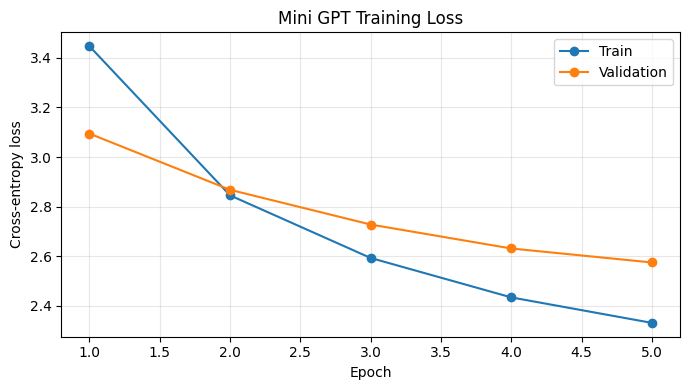

In [31]:
EPOCHS = 5
LEARNING_RATE = 3e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

@torch.no_grad()
def estimate_loss(loader, max_batches=20):
    model.eval()
    losses = []
    for batch_idx, (xb, yb) in enumerate(loader):
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
        if batch_idx + 1 >= max_batches:
            break
    model.train()
    return sum(losses) / len(losses)

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running.append(loss.item())

    train_loss = sum(running) / len(running)
    val_loss = estimate_loss(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train")
plt.plot(range(1, EPOCHS + 1), val_losses, marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Mini GPT Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("hw4_training_loss.png", dpi=160)
plt.show()

## Part 4 - Sampling


In [32]:
prompt = "ROMEO:"
start = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
MAX_NEW_TOKENS = 500

samples = {}

greedy_ids = model.generate(start, max_new_tokens=MAX_NEW_TOKENS, mode="greedy")
samples["greedy"] = decode(greedy_ids[0].tolist())

print("GREEDY DECODING")
print(samples["greedy"])

GREEDY DECODING
ROMEO:
Ther the the thathe athe that that t the the at the t that athe the the ar t t the t the t the the t at the the t t the athe the the the the athe the the athe the the the athe the the the the the the the the athe the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th


In [21]:
temperatures = [0.5, 1.0, 1.5]

for temp in temperatures:
    torch.manual_seed(SEED)
    out_ids = model.generate(start, max_new_tokens=MAX_NEW_TOKENS, mode="temperature", temperature=temp)
    key = f"temperature_{temp}"
    samples[key] = decode(out_ids[0].tolist())
    print(f"\nTEMPERATURE SAMPLING, T={temp}")
    print(samples[key])


TEMPERATURE SAMPLING, T=0.5
ROMEO:
Wherthe s at ner s the ther at ne nome t s al t therthe anat is we athe he we theo we t and, is we t arthad f the wothe all t ar an he he is thathe thal er anaishea at meanore atheathaco al akee t al thal al is the ar thealethe heeaiche s al ishe athe s be t s inome anve i chea ne athe s athame t an areere is it er s seo tanal o t the nar s shere me the ak al theore he the the t we the athethe t ispe t ome here the ise thee s is athar o the sheor are thes thes illl s e we is hee anatheal in s t

TEMPERATURE SAMPLING, T=1.0
ROMEO:dy t bhelefat ner sfagrt hiny wine ?
Sertis me ainduthuthaklt chy shathe het t theovheotleL thisIEA?
Anothad, t

Omeotn wall?
Bawispe ve t bullonot bes me, isd, shat a e wan, ipeathativeot, beSou , bza i l a

’feOco ar thealet se.
eaiche.
Hal ishe ahoue t pak s fasy nonve i ctitone.
I t sme 
I eer we naceothienge er :
Weo Ianal or foupheaf s shLC, wot h al ishe haped hhe a iel ht weseee faOsthHe or phou omea irell:
Nose thier

In [22]:
top_ks = [5, 20]

for k in top_ks:
    torch.manual_seed(SEED)
    out_ids = model.generate(start, max_new_tokens=MAX_NEW_TOKENS, mode="top_k", temperature=1.0, top_k=k)
    key = f"top_k_{k}"
    samples[key] = decode(out_ids[0].tolist())
    print(f"\nTOP-K SAMPLING, k={k}")
    print(samples[key])


TOP-K SAMPLING, k=5
ROMEO:
Therthe sin ther s an t ang atinanenallll tothe titat thanat is we athe s is atheo at t and, is nest nothamesthy isther allo thatho heano is thatathor theris tishat a t s theat athatis ither s a tar t ino al ise a s isthealeaneeotha the stal ishe a he st s h s inomy ane is ititorer the s atha ser se natarthieatheer s see nanal the t il a and sis thot h al ishe taree she a ie the is the al sth a ar ar t nar here tist se thiere is alis she ise atoulors tothar isealllis n se is ise ana arearin s t

TOP-K SAMPLING, k=20
ROMEO:dy t buelefat ner spagrt hiny wine nomertis me ainduthuthaklt chy shathe het t theovheotles this we?
Anothad, thy meotn walld thatho heago bullonot bes me, isotishat a e wan, ipeathativeot, be, e tak t i l al dfe co ar thealet se.
Haiche.
Hal ishe ahoue t pak s fashy anve i ctitone.
I t sme tameer we naceothienge er speeo Ianal or foupheaf s shis, wot h al ishe haped hhe a iel ht weseee fatsth e or phou omea irellipe se thieredo Rort t ove?

## Part 5 - Short Analysis

Greedy decoding always selects the most likely next character. It is usually the most stable and coherent method, but it often repeats itself and can get stuck in bland loops.

Temperature sampling draws from the whole probability distribution after scaling the logits. Lower temperature makes the output more conservative. Higher temperature makes lower-probability characters more likely, increasing variety but also increasing spelling and grammar errors.

Top-k sampling restricts sampling to the k most likely next characters. Here, `k=5` is intentionally narrow and `k=20` is wider, so the two samples should show a clearer diversity difference.

After running the notebook, compare the printed samples. For this small model, the most coherent output is usually greedy decoding or low-temperature sampling, while the most diverse output is usually high-temperature sampling or the larger top-k setting.

In [23]:
# Save a text copy of all generated samples for the findings document.
with open("hw4_decoding_samples.txt", "w", encoding="utf-8") as f:
    for name, sample in samples.items():
        f.write("=" * 80 + "\n")
        f.write(name + "\n")
        f.write("=" * 80 + "\n")
        f.write(sample + "\n\n")

print("Saved hw4_decoding_samples.txt")

Saved hw4_decoding_samples.txt


In [24]:
# Optional: create a PDF findings document from the current run.
from matplotlib.backends.backend_pdf import PdfPages

def add_text_page(pdf, title, lines):
    fig = plt.figure(figsize=(8.5, 11))
    fig.text(0.08, 0.95, title, fontsize=18, weight="bold", va="top")
    y = 0.90
    for line in lines:
        wrapped = textwrap.wrap(line, width=95) or [""]
        for part in wrapped:
            fig.text(0.08, y, part, fontsize=10, va="top")
            y -= 0.025
            if y < 0.07:
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)
                fig = plt.figure(figsize=(8.5, 11))
                y = 0.95
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

with PdfPages("HW4_findings.pdf") as pdf:
    add_text_page(pdf, "HW4 Findings - Mini GPT from Scratch", [
        f"Dataset: {data_path}",
        f"Vocabulary size: {vocab_size}",
        f"Sequence length: {SEQ_LEN}",
        f"Hidden dimension: {HIDDEN_DIM}",
        f"Number of heads: {NUM_HEADS}",
        f"Number of layers: {NUM_LAYERS}",
        f"Total parameters: {total_params:,}",
        f"Epochs: {EPOCHS}",
        f"Learning rate: {LEARNING_RATE}",
        f"Batch size: {BATCH_SIZE}",
        f"Final train loss: {train_losses[-1]:.4f}",
        f"Final validation loss: {val_losses[-1]:.4f}",
    ])

    fig = plt.figure(figsize=(8.5, 5))
    plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train")
    plt.plot(range(1, EPOCHS + 1), val_losses, marker="o", label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("Training Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    add_text_page(pdf, "Decoding Analysis", [
        "Greedy decoding chooses the most likely next character at every step. It is usually coherent but can repeat common patterns.",
        "Temperature sampling changes randomness. Temperature 0.5 is conservative, 1.0 is balanced, and 1.5 is more diverse but less reliable.",
        "Top-k sampling samples only from the k most likely next characters. k=5 is more focused, while k=20 is more diverse.",
        "For this small character model, greedy or temperature 0.5 usually gives the most coherent output. Temperature 1.5 and top-k 20 usually produce the most diverse output.",
    ])

print("Saved HW4_findings.pdf")

Saved HW4_findings.pdf
